# Gaussian Random Field (GRF) CMB realization from best-fit \(C_\ell\)

This notebook:

1. Loads a **best-fit CMB temperature spectrum** \(D_\ell^{TT}\) (CAMB fiducial) and converts it to \(C_\ell\).
2. Draws **one realization** of spherical-harmonic coefficients \(a_{\ell m}\) as a Gaussian random field:
   \[
   a_{\ell 0} \sim \mathcal{N}(0, C_\ell),\qquad
   \mathrm{Re}\,a_{\ell m},\;\mathrm{Im}\,a_{\ell m} \sim \mathcal{N}\!\left(0,\, C_\ell/2\right)\ (m>0).
   \]
3. Builds a full-sky temperature map with `healpy`.
4. Plots the **histogram of the \(a_{\ell m}\)** (normalized by \(\sqrt{C_\ell}\)) against the theoretical unit Gaussian.

The CMB is (to an excellent approximation) a Gaussian isotropic random field on the sphere, fully specified by \(C_\ell\).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from pathlib import Path

# Make paths work whether you run from repo root or notebooks/
DATA = Path("CAMB_fiducial_cosmo_scalCls.dat")
if not DATA.exists():
    DATA = Path("notebooks") / "CAMB_fiducial_cosmo_scalCls.dat"
assert DATA.exists(), f"Cannot find CAMB spectrum at {DATA.resolve()}"

np.random.seed(42)  # reproducible single realization; remove for a new draw
print("healpy", hp.__version__)
print("spectrum:", DATA.resolve())


healpy 1.18.1
spectrum: /Users/licongxu/Study/2026-flatiron-cmb-summer-school/notebooks/CAMB_fiducial_cosmo_scalCls.dat


## 1. Load best-fit CMB \(D_\ell\) and convert to \(C_\ell\)

CAMB files in this school store
\[
D_\ell = \frac{\ell(\ell+1)}{2\pi}\, C_\ell
\]
in \(\mu\mathrm{K}^2\). We invert that to get \(C_\ell\).


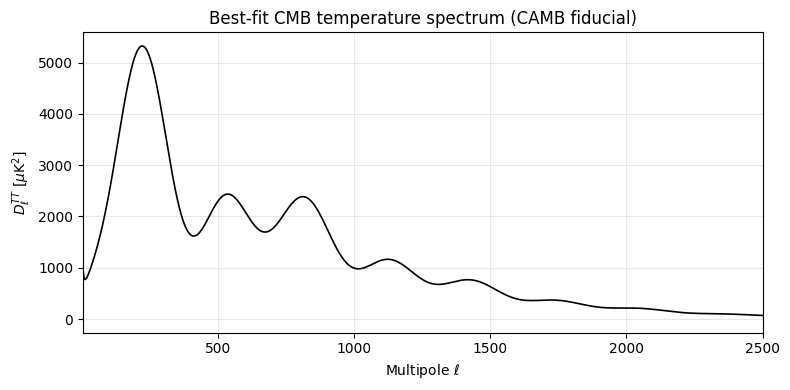

lmax in file = 5000, C_2 = 1.017e+03 uK^2, D_2 = 971.2 uK^2


In [2]:
# columns: ell, TT, ... — use TT
raw = np.loadtxt(DATA)
ell_file = raw[:, 0].astype(int)
DlTT = raw[:, 1]

# Build Cl array indexed by multipole ell = 0 .. lmax_file
lmax_file = int(ell_file.max())
Cl = np.zeros(lmax_file + 1)
for L, Dl in zip(ell_file, DlTT):
    if L >= 2:
        Cl[L] = Dl * 2.0 * np.pi / (L * (L + 1.0))
Cl[0] = 0.0
Cl[1] = 0.0

# Plot D_ell (standard CMB presentation)
ell = np.arange(lmax_file + 1)
Dl = ell * (ell + 1) * Cl / (2.0 * np.pi)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ell[2:], Dl[2:], "k-", lw=1.2)
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell^{TT}\ [\mu\mathrm{K}^2]$")
ax.set_title("Best-fit CMB temperature spectrum (CAMB fiducial)")
ax.set_xlim(2, min(2500, lmax_file))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"lmax in file = {lmax_file}, C_2 = {Cl[2]:.3e} uK^2, D_2 = {Dl[2]:.1f} uK^2")


## 2. Draw one GRF realization: \(a_{\ell m}\) and the map

We use `healpy.synalm` / `healpy.alm2map`, which draw
\[
\langle a_{\ell m} a_{\ell' m'}^*\rangle = C_\ell\,\delta_{\ell\ell'}\delta_{mm'}
\]
and synthesize
\[
T(\hat n)=\sum_{\ell m} a_{\ell m} Y_{\ell m}(\hat n).
\]


nside=512, lmax=1535, npix=3145728
C_1000 = 6.223835e-03 uK^2
map mean = -0.0000 uK,  rms = 108.36 uK


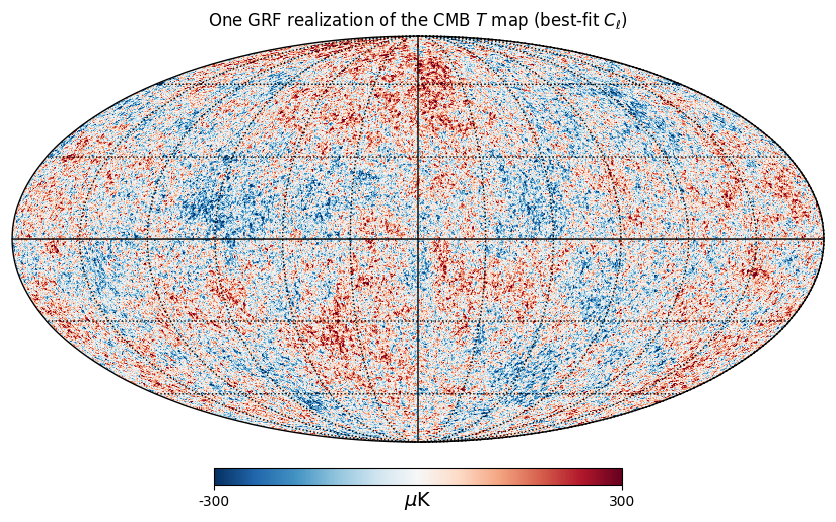

In [3]:
# Need lmax >= 1000 for the ell=1000 a_lm study.
# healpy rule of thumb: lmax ~ 3*nside - 1  →  nside=512 gives lmax=1535
nside = 512
ell_target = 1000
lmax = min(3 * nside - 1, lmax_file)
assert lmax >= ell_target, f"lmax={lmax} < ell_target={ell_target}; increase nside"
Cl_use = Cl[: lmax + 1].copy()

# --- Draw a_lm for one realization (temperature only) ---
alm = hp.synalm(Cl_use, lmax=lmax, new=True)

# --- Map ---
T_map = hp.alm2map(alm, nside=nside, lmax=lmax)

print(f"nside={nside}, lmax={lmax}, npix={hp.nside2npix(nside)}")
print(f"C_{ell_target} = {Cl_use[ell_target]:.6e} uK^2")
print(f"map mean = {T_map.mean():.4f} uK,  rms = {T_map.std():.2f} uK")

hp.mollview(
    T_map,
    title=r"One GRF realization of the CMB $T$ map (best-fit $C_\ell$)",
    unit=r"$\mu\mathrm{K}$",
    cmap="RdBu_r",
    min=-300,
    max=300,
)
hp.graticule(dpar=30, dmer=30)
plt.show()


## 3. \(a_{\ell m}\) at \(\ell = 1000\) vs theoretical Gaussian

Focus on a **single multipole** \(\ell=1000\). There are \(2\ell+1=2001\) real degrees of freedom:

- \(a_{1000,0}\) is real with variance \(C_{1000}\)
- for \(m=1,\ldots,1000\): \(\mathrm{Re}\,a_{\ell m}\) and \(\mathrm{Im}\,a_{\ell m}\) each have variance \(C_{1000}/2\)

We plot:
1. Raw \(\mathrm{Re}/\mathrm{Im}\,a_{1000 m}\) histogram vs \(\mathcal{N}(0, C_{1000}/2)\)
2. Standardized samples vs \(\mathcal{N}(0,1)\)


In [4]:
ell_target = 1000
assert ell_target <= lmax, f"Need lmax >= {ell_target}, got {lmax}"
C_ell = Cl_use[ell_target]
assert C_ell > 0, f"C_{ell_target} is zero — check the spectrum"

# Collect a_lm at ell = 1000
a0 = np.real(alm[hp.Alm.getidx(lmax, ell_target, 0)])
re_im = []
for m in range(1, ell_target + 1):
    idx = hp.Alm.getidx(lmax, ell_target, m)
    re_im.append(np.real(alm[idx]))
    re_im.append(np.imag(alm[idx]))
re_im = np.asarray(re_im)

# Standardized samples (all should be N(0,1))
z_list = [a0 / np.sqrt(C_ell)]
z_list.extend(re_im / np.sqrt(C_ell / 2.0))
z_ell = np.asarray(z_list)

print(f"ell = {ell_target}")
print(f"C_ell = {C_ell:.6e} uK^2")
print(f"D_ell = {ell_target*(ell_target+1)*C_ell/(2*np.pi):.2f} uK^2")
print(f"a_l0 = {a0:.4f} uK  (theory std = {np.sqrt(C_ell):.4f})")
print(f"Re/Im samples: n = {re_im.size}  (expect 2*ell = {2*ell_target})")
print(f"Re/Im sample std = {re_im.std(ddof=1):.5f} uK  (theory sqrt(C/2) = {np.sqrt(C_ell/2):.5f})")
print(f"standardized z: mean = {z_ell.mean():.4f}, std = {z_ell.std(ddof=1):.4f}  (expect ~0, ~1)")
print(f"total real d.o.f. = {z_ell.size}  (expect 2*ell+1 = {2*ell_target+1})")


ell = 1000
C_ell = 6.223835e-03 uK^2
D_ell = 991.54 uK^2
a_l0 = 0.1104 uK  (theory std = 0.0789)
Re/Im samples: n = 2000  (expect 2*ell = 2000)
Re/Im sample std = 0.05545 uK  (theory sqrt(C/2) = 0.05578)
standardized z: mean = -0.0206, std = 0.9942  (expect ~0, ~1)
total real d.o.f. = 2001  (expect 2*ell+1 = 2001)


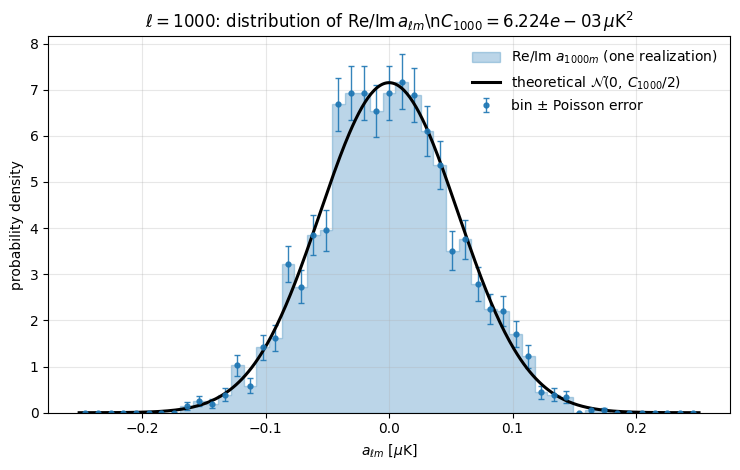

In [5]:
def hist_with_errors(ax, data, bins, color="C0", label=None, density=True):
    """Histogram with Poisson error bars on bin counts (or density)."""
    counts, edges = np.histogram(data, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    # Poisson: sigma(N_i) = sqrt(N_i); for empty bins show no point / zero error
    err_counts = np.sqrt(counts.astype(float))

    if density:
        n_tot = counts.sum()
        # density = count / (N * Delta)
        y = counts / (n_tot * widths)
        yerr = err_counts / (n_tot * widths)
    else:
        y = counts.astype(float)
        yerr = err_counts

    # step/filled hist for appearance
    ax.hist(
        data, bins=bins, density=density, histtype="stepfilled",
        alpha=0.30, color=color, edgecolor=color, label=label,
    )
    # error bars on bin centers
    ax.errorbar(
        centers, y, yerr=yerr, fmt="o", color=color, ms=3.5, lw=1.0,
        capsize=2, alpha=0.9, label="bin ± Poisson error",
    )
    return centers, y, yerr


# --- Histogram at ell=1000: raw Re/Im a_lm vs N(0, C_ell/2) ---
sigma = np.sqrt(C_ell / 2.0)  # std of Re or Im for m>0

fig, ax = plt.subplots(figsize=(7.5, 4.8))
bins = np.linspace(-4.5 * sigma, 4.5 * sigma, 50)
hist_with_errors(
    ax, re_im, bins, color="C0",
    label=fr"Re/Im $a_{{{ell_target}m}}$ (one realization)",
)

xx = np.linspace(-4.5 * sigma, 4.5 * sigma, 400)
gauss = np.exp(-0.5 * (xx / sigma) ** 2) / (sigma * np.sqrt(2.0 * np.pi))
ax.plot(xx, gauss, "k-", lw=2.2, label=fr"theoretical $\mathcal{{N}}(0,\,C_{{{ell_target}}}/2)$")

ax.set_xlabel(r"$a_{\ell m}$ [$\mu\mathrm{K}$]")
ax.set_ylabel("probability density")
ax.set_title(
    fr"$\ell={ell_target}$: distribution of $\mathrm{{Re}}/\mathrm{{Im}}\,a_{{\ell m}}$"
    + fr"\n$C_{{{ell_target}}}={C_ell:.3e}\,\mu\mathrm{{K}}^2$"
)
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


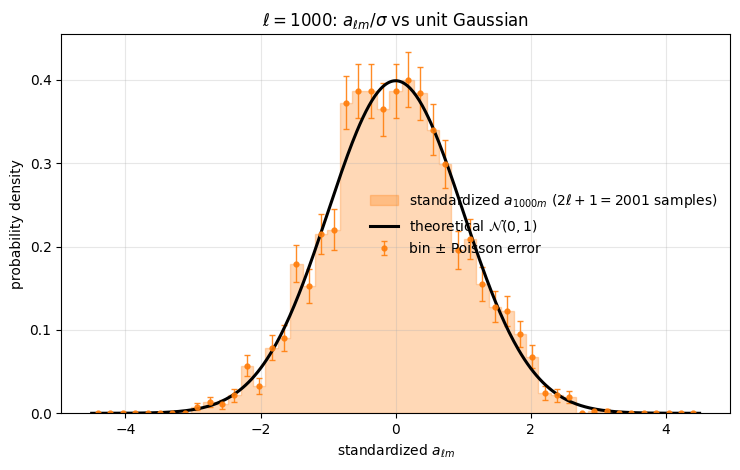

In [6]:
# --- Same modes, standardized → should match N(0,1) ---
fig, ax = plt.subplots(figsize=(7.5, 4.8))
bins = np.linspace(-4.5, 4.5, 50)
hist_with_errors(
    ax, z_ell, bins, color="C1",
    label=fr"standardized $a_{{{ell_target}m}}$ ($2\ell+1={z_ell.size}$ samples)",
)

xx = np.linspace(-4.5, 4.5, 400)
gauss = np.exp(-0.5 * xx**2) / np.sqrt(2.0 * np.pi)
ax.plot(xx, gauss, "k-", lw=2.2, label=r"theoretical $\mathcal{N}(0,1)$")

ax.set_xlabel(r"standardized $a_{\ell m}$")
ax.set_ylabel("probability density")
ax.set_title(fr"$\ell={ell_target}$: $a_{{\ell m}}/\sigma$ vs unit Gaussian")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Sanity check: recovered \(\hat C_\ell\) from this realization

For one sky,
\[
\hat C_\ell = \frac{1}{2\ell+1}\sum_{m=-\ell}^{\ell}|a_{\ell m}|^2
\]
scatters about the input \(C_\ell\) with cosmic variance \(\mathrm{Var}(\hat C_\ell)\approx 2C_\ell^2/(2\ell+1)\).


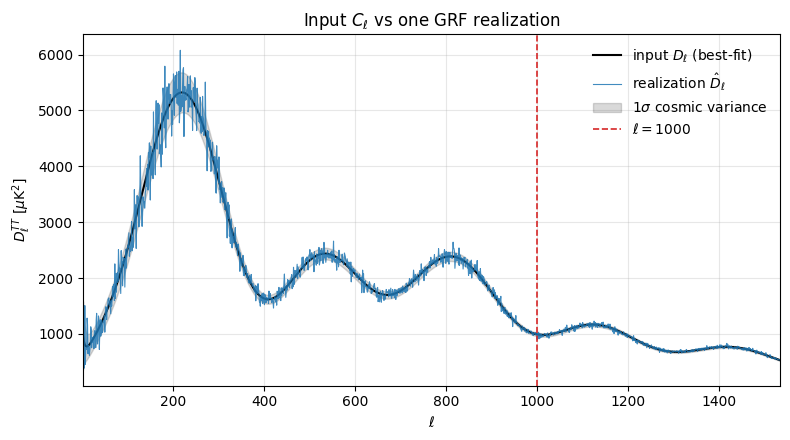

ell=1000:  C_ell input = 6.223835e-03
ell=1000:  C_ell hat    = 6.151094e-03
ratio hat/input = 0.9883


In [7]:
Cl_hat = hp.alm2cl(alm, lmax=lmax)
ell_h = np.arange(len(Cl_hat))
Dl_hat = ell_h * (ell_h + 1) * Cl_hat / (2.0 * np.pi)
Dl_th = ell_h * (ell_h + 1) * Cl_use[: len(ell_h)] / (2.0 * np.pi)

sigma_Cl = np.zeros_like(Cl_hat)
good = ell_h >= 2
sigma_Cl[good] = Cl_use[ell_h[good]] * np.sqrt(2.0 / (2.0 * ell_h[good] + 1.0))
sigma_Dl = ell_h * (ell_h + 1) * sigma_Cl / (2.0 * np.pi)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ell_h[2:], Dl_th[2:], "k-", lw=1.5, label=r"input $D_\ell$ (best-fit)")
ax.plot(ell_h[2:], Dl_hat[2:], "C0-", lw=0.8, alpha=0.85, label=r"realization $\hat D_\ell$")
ax.fill_between(
    ell_h[2:],
    (Dl_th - sigma_Dl)[2:],
    (Dl_th + sigma_Dl)[2:],
    color="k", alpha=0.15, label=r"$1\sigma$ cosmic variance",
)
# mark ell=1000
ax.axvline(ell_target, color="C3", ls="--", lw=1.2, label=fr"$\ell={ell_target}$")
ax.set_xlim(2, min(lmax, 2000))
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$D_\ell^{TT}\ [\mu\mathrm{K}^2]$")
ax.set_title(r"Input $C_\ell$ vs one GRF realization")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# hat C at ell=1000 vs theory
print(f"ell={ell_target}:  C_ell input = {Cl_use[ell_target]:.6e}")
print(f"ell={ell_target}:  C_ell hat    = {Cl_hat[ell_target]:.6e}")
print(f"ratio hat/input = {Cl_hat[ell_target]/Cl_use[ell_target]:.4f}")


## Summary

| Step | What we did |
|------|-------------|
| Spectrum | Best-fit CAMB \(D_\ell^{TT}\) \(\to C_\ell\) |
| GRF draw | \(a_{\ell m}\) via `hp.synalm(Cl)` — one realization |
| Map | `hp.alm2map` full-sky \(T\) |
| Gaussian test | standardized \(a_{\ell m}\) histogram matches \(\mathcal{N}(0,1)\) |
| Power | \(\hat C_\ell\) scatters about input within cosmic variance |

**Takeaway:** specifying \(C_\ell\) fully defines an isotropic Gaussian CMB sky; drawing \(a_{\ell m}\) and synthesizing \(Y_{\ell m}\) is exactly making a GRF realization.

### Requirements
- `numpy`, `matplotlib`, `healpy`
- `notebooks/CAMB_fiducial_cosmo_scalCls.dat` (shipped with this repo)
